In [1]:
# imports
import json
from matplotlib import pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
import time

from analysis.db.queries import run_custom_query
from analysis.utils import label_returns_dynamic


In [2]:
# utils code
def time_execution(func, message: str | None = None):
    print(f"Starting the timer{f' for {message}' if message is not None else ''}...")
    start_time = time.time()
    result = func()
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Elapsed time: {elapsed_time:.4f} seconds")

    return result, elapsed_time


seed = 420

# Load financial dataset

In [3]:
query = """
select
    timeframe,
    symbol,
    open,
    close,
    volume,
    log_return_1d,
    log_return_1w,
    log_return_1m,
    return_1d,
    return_1w,
    return_1m,
    open_rolling_1w,
    open_rolling_1m,
    open_rolling_1q,
    volatility_1w,
    volatility_1m,
    sharpe_1w,
    sharpe_1m,
from read_parquet('./dataplatform/transformed/stock_daily/**/*.parquet', hive_partitioning=true)
where year >= 2000
and open is not null
and close is not null
"""
df = run_custom_query(query)
# one week future returns
thresholds = [0.01, 0.03]
sorted_class_labels = [">3% lost", "lost betwe 1-3%", "stagnant", "gained between 1-3%", "gained more than 3%"]
df = label_returns_dynamic(df, thresholds=thresholds, steps=5)



In [4]:
# drop latest rows for which the label is not available
df = df.dropna(subset="label")
# encode symbols ans unique integers
encoder = LabelEncoder()
df['symbol'] = encoder.fit_transform(df['symbol'])
df = df.drop(columns=['timeframe', 'open_future_5', 'future_return_5'])
numeric_cols = df.select_dtypes(include=[np.number]).columns
# drop infinity values as they conflict with DT training
bad_rows = df[numeric_cols].replace([np.inf, -np.inf], np.nan).isna().any(axis=1)
df = df[~bad_rows]

In [5]:
print(f"working with columns ({df.shape[1]}): {df.columns}")
print(f"total samples {df.shape[0]}")
print(f"memory usage of the dataset {df.memory_usage().sum() / 1024**3}GB")
print(f"computed return labels: {df['label'].unique()}")
print(df.head())

x, y = df.drop(columns='label'), df['label']
xtrain, xtest, ytrain, ytest = train_test_split(x,y, train_size=0.7, stratify=y)
print(f"trainset size {xtrain.shape[0]} rows, {xtrain.memory_usage().sum() / 1024**3}GB")



working with columns (18): Index(['symbol', 'open', 'close', 'volume', 'log_return_1d', 'log_return_1w',
       'log_return_1m', 'return_1d', 'return_1w', 'return_1m',
       'open_rolling_1w', 'open_rolling_1m', 'open_rolling_1q',
       'volatility_1w', 'volatility_1m', 'sharpe_1w', 'sharpe_1m', 'label'],
      dtype='object')
total samples 26887916
memory usage of the dataset 3.8062811195850372GB
computed return labels: [0. 3. 4. 2. 1.]
        symbol       open      close     volume  log_return_1d  log_return_1w  \
237790       0  47.155195  43.113323  4674353.0      -0.071189       0.309918   
237791       0  40.792984  39.819942  4765083.0      -0.079464       0.078165   
237792       0  39.670241  37.349907  5758642.0      -0.064037      -0.143502   
237793       0  36.900802  35.927757  2534434.0      -0.038820      -0.278263   
237827       0  35.366393  38.921745  2819626.0       0.080043      -0.173468   

        log_return_1m  return_1d  return_1w  return_1m  open_rolling_

In [ ]:
# free memory
df = None
x = None
y = None

# Some data visualization

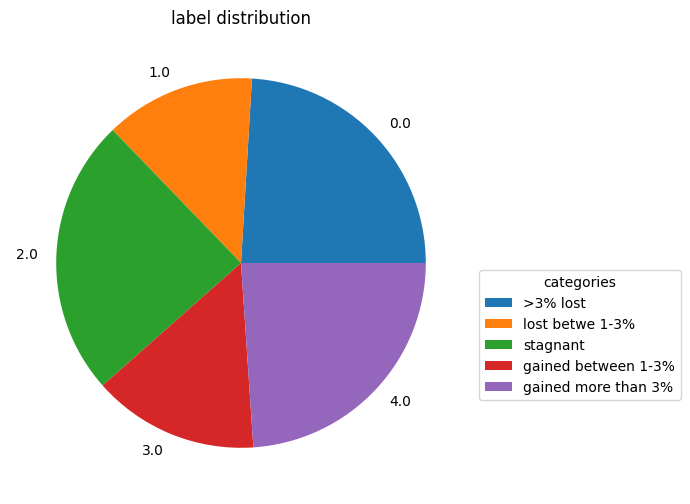

In [7]:
counts = ytrain.value_counts().sort_index()
plt.figure(figsize=(10, 6)) 
plt.pie(x=counts.values, labels=counts.index)
plt.title("label distribution")
handles = [str(l) for l in counts.index]
plt.legend(
    sorted_class_labels,
    title="categories",
    bbox_to_anchor=(1, 0.5)
)
plt.show()

# Classifier definitions with relative hyperparameter grids + train

In [8]:
model_configs = [
    {
        "model": DecisionTreeClassifier(),
        "params": {
            "max_depth": [5, 10, 15, 20],
            "min_samples_split": [2, 10,20],
            "max_features": [None, "sqrt"],
            "ccp_alpha": [0.0, 0.01, 0.1 ],
            "class_weight": [None, 'balanced']
        }
    },
    # {
    #     "model": SGDClassifier(),
    #     "params": {
    #         "eta0": [0.1,0.01,0.001],
    #         "learning_rate": ["optimal", "constant"],
    #         "alpha": [1,0.1,0.001,0.0001],
    #         "loss": ["squared_error"],
    #         "penalty": ["l2"],
    #         "early_stopping": [True],
    #         "validation_fraction": [0.1],
    #     }
    # },
    # {
    #     "model": RandomForestClassifier(),
    #     "params": {
    #         "n_estimators": [50, 100],
    #         "max_depth": [10, 20],
    #         "max_features": [
    #             "sqrt",
    #             # “log2”,
    #             None
    #         ]
    #     }
    # },
    # {
    #     "model": HistGradientBoostingClassifier(),
    #     "params": {
    #         "learning_rate": [
    #             0.1,
    #             # 1, 0.01
    #         ],
    #         "max_iter": [50],
    #         "l2_regularization": [0],
    #         "max_depth": [10],
    #     }
    # }
]
# scores = [
#     'accuracy',
#     # 'precision',
#     # 'recall'
# ]

In [ ]:
reports = []
cv = StratifiedKFold(n_splits=8, shuffle=True)

for config in model_configs:
    # for score in scores:
        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config['params'],
            # scoring=score,
            scoring="f1_micro",
            cv=cv
        )
        _, duration = time_execution(
            lambda: grid.fit(X=xtrain, y=ytrain),
            message=f"grid search of {config['model']}"
        )
        print(f'received duration {duration}')

        prediction = grid.predict(xtest)
        report: dict = classification_report(y_pred=prediction, y_true=ytest, output_dict=True) # type: ignore
        search_report = {
            "model": str(config["model"]),
            "duration": duration,
            "accuracy": report["accuracy"],
            "precision": report["weighted avg"]["precision"],
            "recall": report["weighted avg"]["recall"],
            "f1-score": report["weighted avg"]["f1-score"],
            "support": report["weighted avg"]["support"],
            "best_params": grid.best_params_
        }
        reports.append(search_report)

        with open("./runresult.json", "w") as f:
            json.dump(reports, f, indent=2)

Starting the timer for grid search of DecisionTreeClassifier()...
